In [71]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Activation, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalMaxPool2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import os

In [72]:
def check_images(folder):
    bad = []
    for root, _, files in os.walk(folder):
        for f in files:
            path = os.path.join(root, f)
            try:
                img = Image.open(path)
                img.verify()
            except:
                bad.append(path)

    return bad

bad_images = check_images("../data/Mushrooms")

print("Imagini corupte:", len(bad_images))
for b in bad_images[:10]:
    print(b)

Imagini corupte: 0


In [73]:
def split_mushrooms_dataset(data_root, train_ratio=0.7, test_ratio=0.2, valid_ratio=0.1):
    source_dir = os.path.join(data_root, "Mushrooms")

    all_files = []
    for root, _, files in os.walk(source_dir):
        for f in files:
            all_files.append(os.path.join(root, f))

    random.shuffle(all_files)

    n_total = len(all_files)
    n_train = int(train_ratio * n_total)
    n_test = int(test_ratio * n_total)
    n_valid = n_total - n_train - n_test

    train_files = all_files[:n_train]
    test_files = all_files[n_train:n_train+n_test]
    valid_files = all_files[n_train+n_test:]

    return train_files, test_files, valid_files

DATA_ROOT = "../data"
train_set, test_set, valid_set = split_mushrooms_dataset(DATA_ROOT)

print("Train:", len(train_set))
print("Test:", len(test_set))
print("Validation:", len(valid_set))

Train: 9399
Test: 2685
Validation: 1344


In [74]:
def add_columns(df, split_name):
    df["split"] = split_name
    df["class"] = df["image_path"].apply(
        lambda x: os.path.basename(os.path.dirname(x))
    )
    return df

In [75]:
train_df = pd.DataFrame(train_set, columns=["image_path"])
test_df  = pd.DataFrame(test_set, columns=["image_path"])
valid_df = pd.DataFrame(valid_set, columns=["image_path"])

train_df = add_columns(train_df, "train")
test_df  = add_columns(test_df, "test")
valid_df = add_columns(valid_df, "validation")

df_all = pd.concat([train_df, test_df, valid_df], ignore_index=True)

In [76]:
df_all.head(10)

,image_path,split,class
0,../data\Mushrooms\Hygrocybe\204_BNvLsMFKxc4.jpg,train,Hygrocybe
1,../data\Mushrooms\Mushrooms\Boletus\0737_AKZDD...,train,Boletus
2,../data\Mushrooms\Mushrooms\Cortinarius\072_dx...,train,Cortinarius
3,../data\Mushrooms\Mushrooms\Agaricus\246_tQ0l4...,train,Agaricus
4,../data\Mushrooms\Boletus\0496_oW-MXvWIdeg.jpg,train,Boletus
5,../data\Mushrooms\Mushrooms\Amanita\717_vlDmzu...,train,Amanita
6,../data\Mushrooms\Mushrooms\Boletus\0352_LzZEI...,train,Boletus
7,../data\Mushrooms\Cortinarius\565_KvDrWFEjqxg.jpg,train,Cortinarius
8,../data\Mushrooms\Lactarius\0542_lmuddV_aAUE.jpg,train,Lactarius
9,../data\Mushrooms\Amanita\411_nNTJfhqvBRI.jpg,train,Amanita


In [77]:
IMG_SIZE   = (80, 80)
Batch_size = 32
Epochs     = 20
Num_classes = 36

DATA_ROOT  = "../data"
TRAIN_DIR  = os.path.join(DATA_ROOT, "train")
TEST_DIR   = os.path.join(DATA_ROOT, "test")
VALID_DIR  = os.path.join(DATA_ROOT, "validation")

tf.random.set_seed(42)
np.random.seed(42)

In [78]:
df_all.shape

(13428, 3)

In [79]:
df_all.isnull().sum()

image_path    0
split         0
class         0
dtype: int64

In [80]:
df_all['class'].nunique()

9

In [81]:
df_all['split'].value_counts()

split
train         9399
test          2685
validation    1344
Name: count, dtype: int64

In [82]:
sorted(df_all['class'].unique())

['Agaricus',
 'Amanita',
 'Boletus',
 'Cortinarius',
 'Entoloma',
 'Hygrocybe',
 'Lactarius',
 'Russula',
 'Suillus']

C:\Users\Costea\AppData\Local\Temp\ipykernel_220932\2355285615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y='class', order=order, palette='viridis')


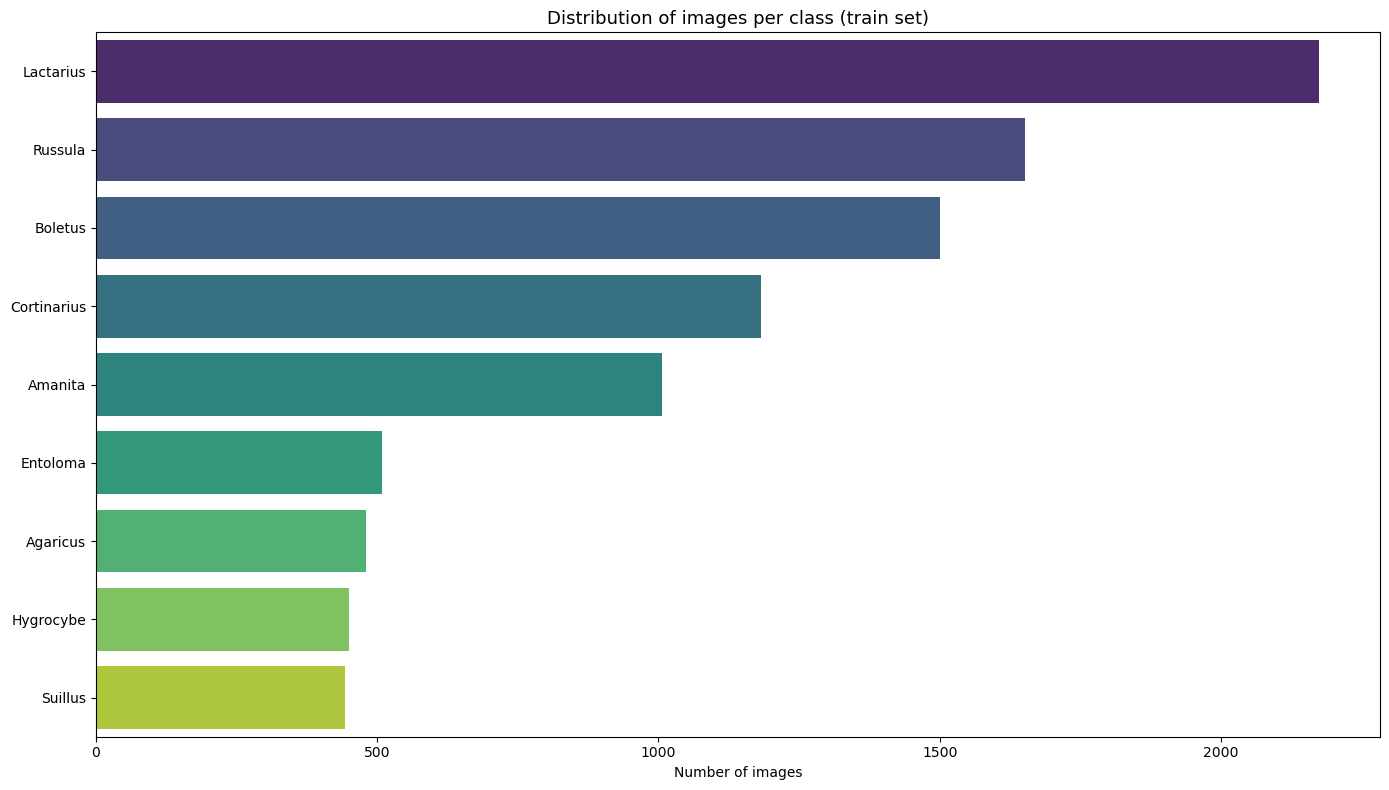

In [83]:
plt.figure(figsize=(14, 8))
order = train_df['class'].value_counts().index
sns.countplot(data=train_df, y='class', order=order, palette='viridis')
plt.title('Distribution of images per class (train set)', fontsize=13)
plt.xlabel('Number of images')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\Costea\AppData\Local\Temp\ipykernel_220932\2579088059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='split', order=['train', 'validation', 'test'], palette='Set2')


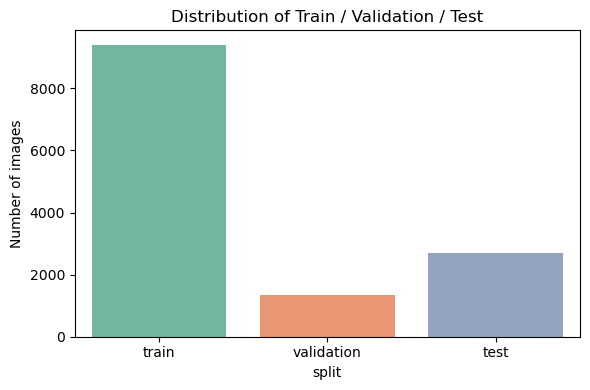

In [84]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_all, x='split', order=['train', 'validation', 'test'], palette='Set2')
plt.title('Distribution of Train / Validation / Test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

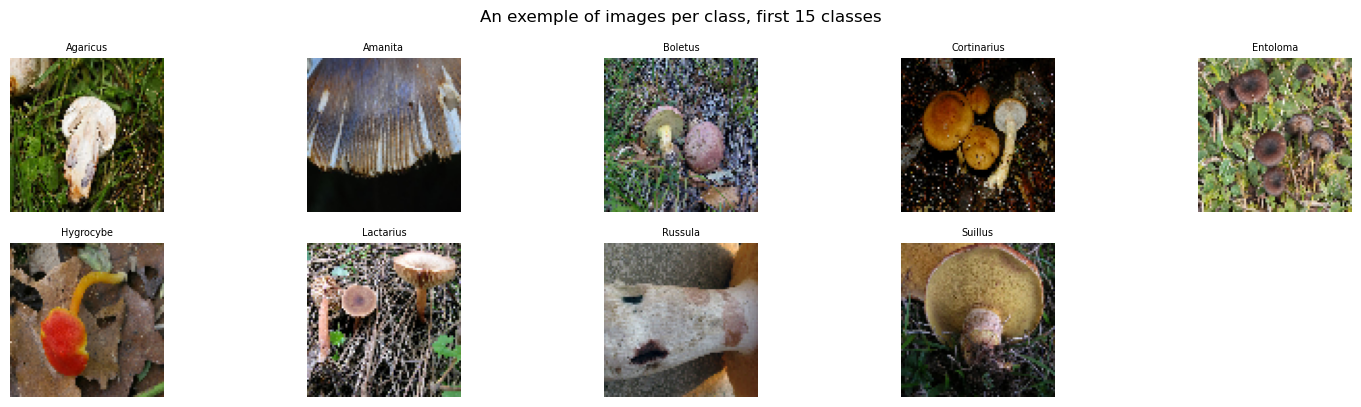

In [85]:
plt.figure(figsize=(15, 6))
sample = train_df.groupby('class').first().reset_index().head(15)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    img = load_img(row['image_path'], target_size=(80, 80))
    plt.subplot(3, 5, i)
    plt.imshow(img)
    plt.title(row['class'], fontsize=7)
    plt.axis('off')
plt.suptitle('An exemple of images per class, first 15 classes')
plt.tight_layout()
plt.show()

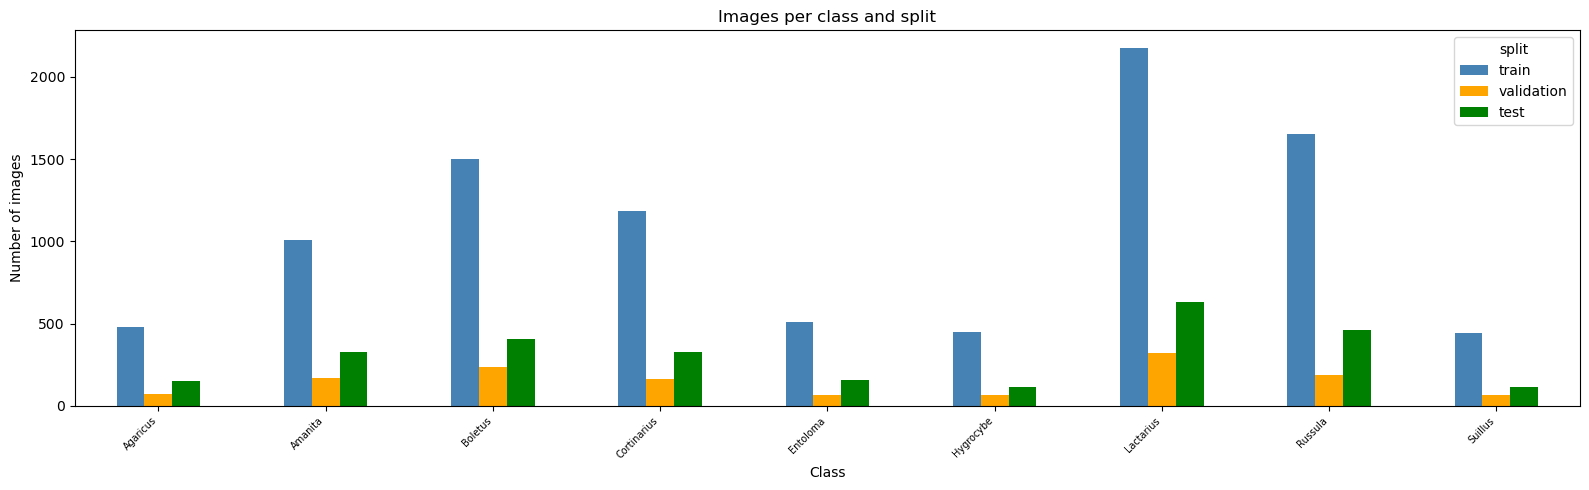

In [86]:
class_counts = df_all.groupby(['class', 'split']).size().unstack(fill_value=0)
class_counts[['train', 'validation', 'test']].plot(
    kind='bar', figsize=(16, 5), color=['steelblue', 'orange', 'green'])
plt.title('Images per class and split')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [88]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="image_path",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode="categorical",
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
Num_classes = len(CLASS_NAMES)

print(f"\nNumăr clase detectate: {Num_classes}")
print("Clase:", CLASS_NAMES)

Found 9399 validated image filenames belonging to 9 classes.
Found 1344 validated image filenames belonging to 9 classes.
Found 2685 validated image filenames belonging to 9 classes.

Număr clase detectate: 9
Clase: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']


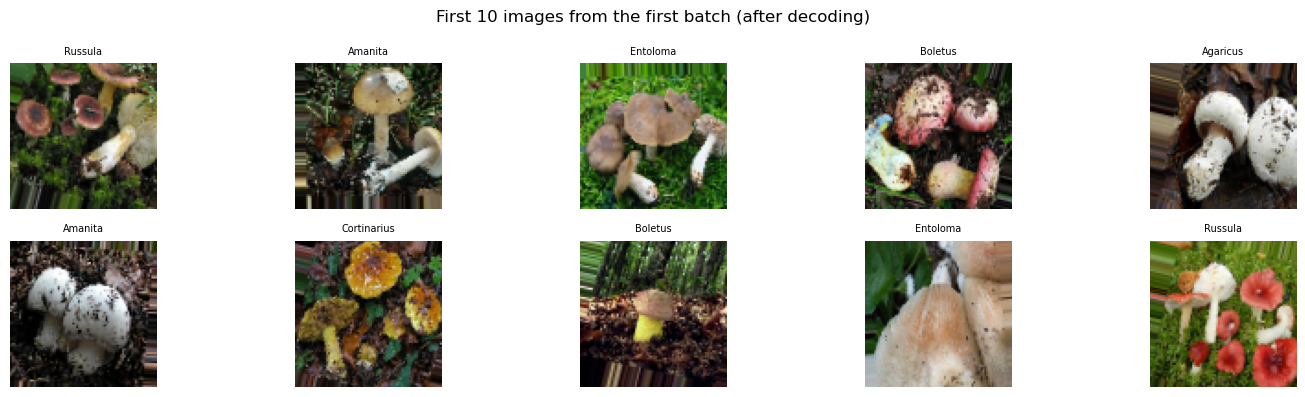

In [89]:
plt.figure(figsize=(15, 4))
batch_x, batch_y = next(train_gen)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch_x[i])
    plt.title(CLASS_NAMES[np.argmax(batch_y[i])], fontsize=7)
    plt.axis('off')
plt.suptitle('First 10 images from the first batch (after decoding)')
plt.tight_layout()
plt.show()

In [90]:
model = Sequential()

model.add(Input(shape=(80, 80, 3)))

model.add(Conv2D(filters=32, kernel_size=(7, 7), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, kernel_size=(5, 5), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(GlobalMaxPool2D())

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(Num_classes))
model.add(Activation('softmax'))

In [91]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 80, 80, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 36, 36, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,086,153 (4.14 MB)

 Trainable params: 1,084,681 (4.14 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [92]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Training")

history = model.fit(
    train_gen,
    epochs=10,
    steps_per_epoch=20,
    validation_data=val_gen,
    verbose=1
)


Model Training
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2078 - loss: 3.7150 - val_accuracy: 0.1875 - val_loss: 2.1251
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.2156 - loss: 2.4259 - val_accuracy: 0.1771 - val_loss: 2.1990
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2562 - loss: 2.0790 - val_accuracy: 0.1815 - val_loss: 2.3870
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2766 - loss: 1.9891 - val_accuracy: 0.1801 - val_loss: 2.4604
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3187 - loss: 1.9355 - val_accuracy: 0.1778 - val_loss: 2.2975
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 996ms/step - accuracy: 0.3250 - loss: 1.9064 - val_accuracy: 0.1771 - val_loss: 3.1051
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 987ms/step - accuracy: 0.3027 - loss: 1.8870 - val_accuracy: 0.1771 - val_loss: 3.0032
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3594 - loss: 1.8348 - val_accura

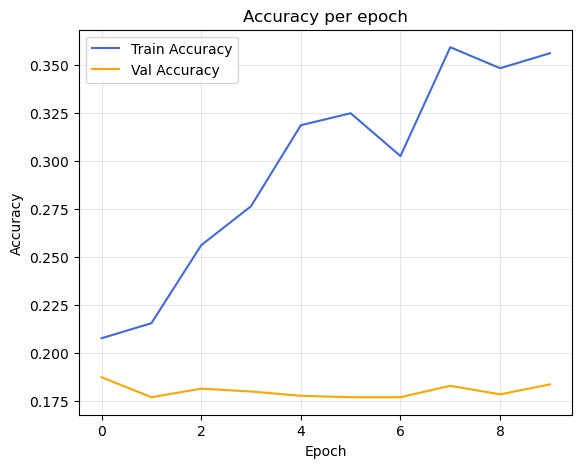

In [93]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Accuracy per epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

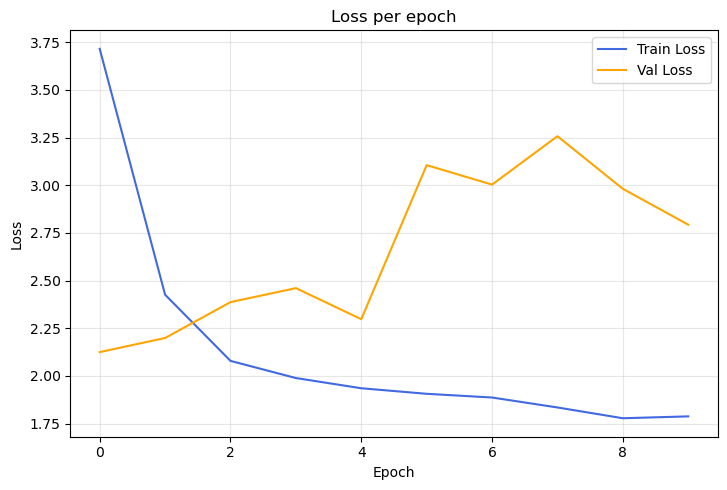

In [94]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss per epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
loss, accuracy = model.evaluate(test_gen, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


Test Loss: 2.8939
Test Accuracy: 0.1583 (15.83%)


In [96]:
def predict_imagine(img_path):
    img       = load_img(img_path, target_size=(80, 80))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs     = model.predict(img_array, verbose=0)[0]
    idx       = np.argmax(probs)
    clasa     = CLASS_NAMES[idx]
    incredere = probs[idx]

    top3_idx  = np.argsort(probs)[::-1][:3]

    print(f"Clasă prezisă : {clasa}")
    print(f"Încredere     : {incredere*100:.1f}%")
    print(f"Top 3 predicții:")
    for i in top3_idx:
        print(f"  {CLASS_NAMES[i]:20s}: {probs[i]*100:.1f}%")

In [97]:
predict_imagine("../data/Mushrooms/Mushrooms/Amanita/516_z1apmvbvlTg.jpg")

Clasă prezisă : Boletus
Încredere     : 59.1%
Top 3 predicții:
  Boletus             : 59.1%
  Amanita             : 11.7%
  Lactarius           : 10.8%


In [98]:
predict_imagine("../data/Mushrooms/Mushrooms/Agaricus/000_ePQknW8cTp8.jpg")

Clasă prezisă : Boletus
Încredere     : 70.4%
Top 3 predicții:
  Boletus             : 70.4%
  Lactarius           : 10.8%
  Amanita             : 8.9%
